<img src="./src/LogoUTNNegro.png" align="right" width="150">

#### Teoría de los Circuitos 2

# Trabajo Semanal 2
#### Renzo Villani

### Consignas

Para  la siguiente red se pide:

<center><img src="./src/img1_TS2.png" width="1000"></center>

**Consignas de la actividad**:
1. Hallar la transferencia $T = \frac{V_o}{V_i}$ en función de $\omega_o$ y $Q$.
2. Hallar los parámetros $\omega_o$, $Q$ y $k$.
3. Cómo podría obtener un circuito pasabanda con los mismos componentes originales y con qué parámetros quedaría diseñado ( Ver ejemplo **4.6** en Schaumann , **pag. 159** ).
4. Se pide implementar un filtro pasabajos Chebyshev que cumpla con la siguiente plantilla. Debera interconectar mas de una red como la aquí presentada en configuración cascada. De ser necesario incluya una red de orden 1 pasabajos RC.

<center><img src="./src/img2_TS2.png" width="1000"></center>

**Bonus**
- 💎 Obtener los valores de la red normalizados en frecuencia e impedancia.
- 💎 Simulación en Python de la Transferencia *normalizada*.
- 💎 Simulación Circuital de la red con los valores normalizados. Simule la respuesta de modulo en forma *aramétrica* convenientemente para graficar curvas pasabanda con Q: 1:100 en pasos de 10.

### Punto 1

Calculo la transferencia $T(s)=\frac{V_o}{V_i}$ nuevamente por **nodos**.

<center><img src="./src/img3_TS2.png" width="800"></center>

Con el álgebra  llego a la transferencia:

## <center>$T(s)=\frac{V_2(s)}{V_1(s)}=\frac{-\frac{1}{CR_1R_3}}{s²+s(\frac{1}{CR_2})+\frac{1}{C²R_3²}}$</center>

La transferencia corresponde a un ***filtro pasabajos de 2do orden***.

### Punto 2

Los parámetros del filtro son:
#### - $\omega_o = \frac{1}{CR_3}$
#### - $Q = \frac{R_2}{R_3}$
#### - $K = -\frac{R_3}{R_1}$

Podemos expresar la trasnferencia en función de los parámetros $\omega_o$, $Q$ y $k$.

## <center>$T(s)=\frac{V_2(s)}{V_1(s)}=\frac{(-\frac{R_3}{R_1})\frac{1}{C²R_3²}}{s²+s(\frac{1}{CR_3}\frac{R_3}{R_2})+\frac{1}{C²R_3²}}$</center>

### Punto 3

En el Schauman indica que para obtener un pasa banda de 2do orden de la misma red circuital hay que tomar la salida del 1er operacional.
<center><img src="./src/img4_TS2.png" width="1000"></center>

Calculo la transferencia $T(s)=\frac{V_o}{V_i}$ nuevamente por **nodos**.
<center><img src="./src/img5_TS2.png" width="1000"></center>

Los parámetros del filtro son:
#### - $\omega_o = \frac{1}{CR_3}$
#### - $Q = \frac{R_2}{R_3}$
#### - $K = -\frac{R_2}{R_1}$
#### - $B = \frac{1}{CR_2}$

### Punto 4

Con el dato del riple calculo $\epsilon$. Luego itero sobre la función de atenuación de Chebyshev para obtener el order del filtro.
<center><img src="./src/img6_TS2.png" width="800"></center>

Para implementar el filtro voy a necesitar dos celdas bajo estudio concatenadas con un pasabajos de 1er orden.
<center><img src="./src/img7_TS2.png" width="1000"></center>

Para calcular el filtro se necesita el 5to polinomio de Chebyshev.
<center><img src="./src/img8_TS2.png" width="800"></center>

Hago el cambio de variable $s = j\omega$.
<center><img src="./src/img9_TS2.png" width="800"></center>

Sigo el procedimiento vía código: Obtengo los polos del filtro.

In [8]:
# Importo las librerías para trabajar de acá en adelante.

# Librerías externas NumPy, SciPy y Matplotlib
from scipy.signal import TransferFunction
from scipy import signal as sig
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

# Librería de TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot, analyze_sys, tf2sos_analog

from pytc2.general import a_equal_b_latex_s, print_latex

[-0.11932228+1.01949544j -0.11932228-1.01949544j -0.31238979+0.63008283j
 -0.31238979-0.63008283j -0.38613502+0.j        ]


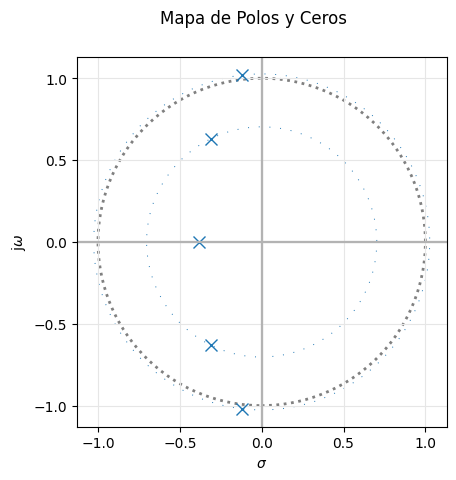

In [9]:
alfMax = 0.4

order = 5

# Para obtener la función transferencia del Cheby vía código directamente
# z,p,k = sig.cheb1ap(order, alfMax)
# num, den = sig.zpk2tf(z,p,k)

# Pero esta vez lo voy a hacer de forma manual

eps = np.sqrt( 10**(alfMax/10) - 1 )   # 0.3106093948083108

# Construyo |T|²
numsq = np.sqrt(1/256/ eps**2)
den = np.array([1, 0, 640/256, 0, 560/256, 0, 200/256, 0 , 25/256, 0 , -1/256/ eps**2])
Tsq = TransferFunction(numsq, den)   

# Contruyo la transferencia Cheby
num = np.sqrt(1/256/ eps**2)
roots = np.roots(den)
roots = roots[ np.real(roots) < 0 ]   # filtro los polos del semiplano derecho
den = np.poly(roots)
T = TransferFunction(num, den)

pzmap(T)
print(roots)

Polos:
- $s = -0,11932228 \pm 1,01949544j$
- $s = -0,31238979 \pm 0,63008283j$
- $s = -0,38613502$

Como ya conozco la ubicación de cada polo puedo repartir a estos en celdas bicuadradas para hacer la implementación.

In [10]:
poles1 = np.array([
    -0.11932228 + 1.01949544j,
    -0.11932228 - 1.01949544j
])

poles2 = np.array([
    -0.31238979 + 0.63008283j,
    -0.31238979 - 0.63008283j
])

poles3 = np.array([
    -0.38613502+0.j
])

zeros = [] 

num1, den1 = sig.zpk2tf(zeros, poles1, 1)
num2, den2 = sig.zpk2tf(zeros, poles2, 1)
num3, den3 = sig.zpk2tf(zeros, poles3, 1)

# Fijo los numeradores para 0dB
num1 = den1[2]
num2 = den2[2]
num3 = den3[1]

# Contruyo las expresiones
s = sp.symbols("s");

num1_expr = num1
den1_expr = s**2 + s*den1[1] + den1[2]
num2_expr = num2
den2_expr = s**2 + s*den2[1] + den2[2]
num3_expr = num3
den3_expr = s + den3[1]

T1_expr = num1_expr / den1_expr
T2_expr = num2_expr / den2_expr
T3_expr = num3_expr / den3_expr

print_latex(a_equal_b_latex_s('T1(s)', T1_expr))
print_latex(a_equal_b_latex_s('T2(s)', T2_expr))
print_latex(a_equal_b_latex_s('T3(s)', T3_expr))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Con la transferencia de cada etapa puedo calcular los valores normalizados de los componentes.
<center><img src="./src/img10_TS2.png" width="800"></center>

- $C_A = 0,9742$
- $R_{1A} = 1$
- $R_{2A} = 4,301$
- $R_{3A} = 1$

- $C_B = 1,4219$
- $R_{1B} = 1$
- $R_{2B} = 1,1256$
- $R_{3B} = 1$

- $C_F = 1$ (elegido)
- $R_F = 2,59$

### Bonus 1

Hago al desnormalización en frecuencia para acomodar $\omega_o$ y la desnormalizaciones de impedancia de cada etapa para obtener los valores de las resistencias para que todos los capacitores sean de valor $C = 100nF$.

<center><img src="./src/img11_TS2.png" width="800"></center>

Los valores de los componentes desnormalizados son:
- $C_A = C_B = C_F = 100nF$
- $R_F = 1,288K\Omega$

- $R_{1A} = 484,527\Omega$
- $R_{2A} = 2,084K\Omega$
- $R_{3A} = 484,527\Omega$

- $R_{1B} = 707,195\Omega$
- $R_{2B} = 796,019\Omega$
- $R_{3B} = 707,195\Omega$

**Nota**: Ambas resistencias que controlan la ganancia de cada inversor son iguales y les di valor de $1K\Omega$.

### Bonus 2

Simulo la transferencia normalizada en *Python* y de paso también la atenuación.

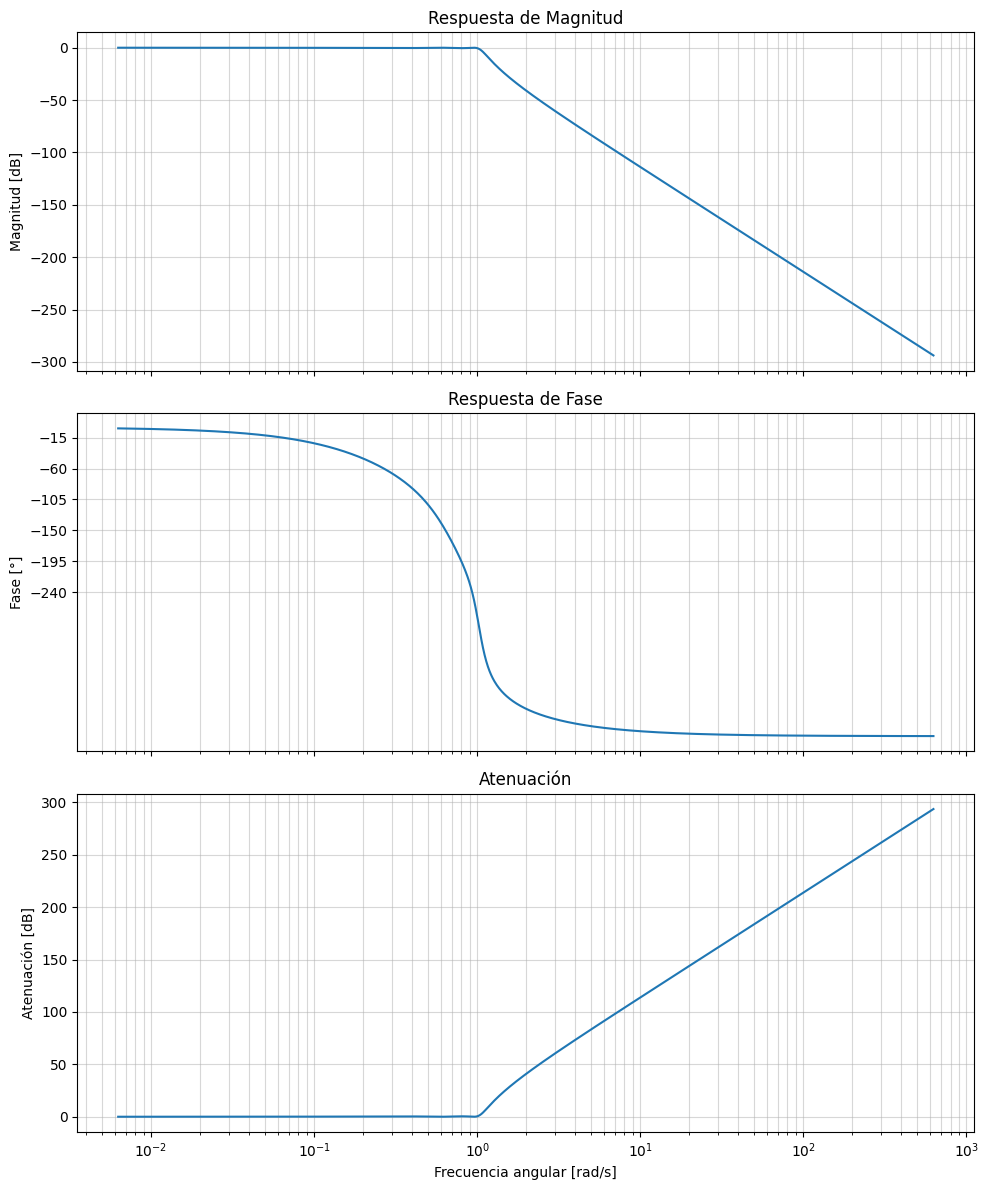

In [7]:
f = np.logspace(-3, 2, 1000)

w = 2*np.pi*f

w, mag, phase = sig.bode(T,w)

fig, (ax_mag, ax_phase, ax_atn) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

attenuation_db = -mag

# Gráfico de Magnitud
ax_mag.semilogx(w, mag)
ax_mag.set_title('Respuesta de Magnitud')
ax_mag.set_ylabel('Magnitud [dB]')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)


# Gráfico de Fase
ticks = np.arange(-240, 181, 45)
ax_phase.set_yticks(ticks)

ax_phase.semilogx(w, phase)
ax_phase.set_title('Respuesta de Fase')
ax_phase.set_ylabel('Fase [°]')
ax_phase.grid(True, which="both", ls="-", alpha=0.5)

# Gráfico de Atenuación
ax_atn.semilogx(w, attenuation_db)
ax_atn.set_title('Atenuación')
ax_atn.set_ylabel('Atenuación [dB]')
ax_atn.set_xlabel('Frecuencia angular [rad/s]')
ax_atn.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

Se puede ver como la atenuación cumple con lo que pide la plantilla.

### Bonus 3

Simulo la transferencia desnormalizada en *LTspice*.

<center><img src="./src/img12_TS2.jpeg" width="800"></center>

<center><img src="./src/img13_TS2.jpeg" width="1000"></center>

La simulación circuital también coincide con los esperado.

### Conclusión

En esta tarea semanal su pudo poner a prueba la estructura circuital **Ackerberg - Mossberg**. Esta red activa presenta una serie ventajas.
- Control de parámetros de forma independiente.
- Dependiendo de la toma de salida se tratará de un pasabajos o un pasabanda.
- Salidas con caracteristicas de seguidor (recordar que son las salidas de operacionales).

En conjunto, el trabajo muestra la coherencia entre el modelo teórico, la normalización del prototipo y su realización práctica, evidenciando la utilidad de estas metodologías para el diseño sistemático de filtros activos.